# 📊 Dataset Comparison: SUN Database vs LDPolypVideo
### Deep Learning-Based Polyp Segmentation in Colonoscopy

This notebook trains the **same U-Net baseline** on both datasets and compares:
- **Training Loss** per epoch
- **Validation Accuracy**
- **Dice Coefficient**
- **IoU (Intersection over Union)**

## ⚙️ 0. Setup & Imports

In [1]:

import os
import cv2
import glob
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, Subset
import torch.nn as nn
import torch.optim as optim

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

# ---- Paths ----
PROJECT_ROOT = Path('/Users/alokkumarshukla/Desktop/Major Project 1')
SUN_PATH = PROJECT_ROOT / 'Sun' / 'sundatabase_positive_part1'
LD_TRAIN_PATH = PROJECT_ROOT / 'LD Polyp' / 'TrainValid'
LD_TEST_PATH = PROJECT_ROOT / 'LD Polyp' / 'Test'

IMAGE_SIZE = (128, 128)
BATCH_SIZE = 8
EPOCHS = 5
SUBSET = 1000   # samples per dataset for fair comparison


Using device: mps


## 📁 1. Dataset Loaders

In [2]:

def read_rgb_image(img_path):
    """Read an image with OpenCV and return RGB format."""
    img = cv2.imread(str(img_path))
    if img is None:
        raise FileNotFoundError(f'Could not read image: {img_path}')
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def add_box_to_mask(mask, box):
    """Add one xmin,ymin,xmax,ymax bounding box to a binary mask."""
    h, w = mask.shape[:2]
    x1, y1, x2, y2 = [int(float(v)) for v in box[:4]]
    x_min, x_max = sorted((max(0, min(w, x1)), max(0, min(w, x2))))
    y_min, y_max = sorted((max(0, min(h, y1)), max(0, min(h, y2))))
    if x_max > x_min and y_max > y_min:
        mask[y_min:y_max, x_min:x_max] = 1


class BoundingBoxSegmentationDataset(Dataset):
    """Common image + bounding-box pseudo-mask dataset behavior."""
    def __init__(self, image_size=IMAGE_SIZE):
        self.image_size = image_size
        self.samples = []

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, boxes = self.samples[idx]
        img = read_rgb_image(img_path)
        h, w = img.shape[:2]
        mask = np.zeros((h, w), dtype=np.uint8)

        for box in boxes:
            add_box_to_mask(mask, box)

        img = cv2.resize(img, self.image_size).astype(np.float32) / 255.0
        mask = cv2.resize(mask, self.image_size, interpolation=cv2.INTER_NEAREST)
        img = np.transpose(img, (2, 0, 1))

        return (
            torch.tensor(img, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.float32).unsqueeze(0),
        )


# ──────────────────────────────────────────────────
#  SUN Database Loader
#  Annotation format: "filename xmin,ymin,xmax,ymax,label"
# ──────────────────────────────────────────────────
class SUNPolypDataset(BoundingBoxSegmentationDataset):
    def __init__(self, root_dir, image_size=IMAGE_SIZE):
        super().__init__(image_size=image_size)
        root_dir = Path(root_dir)
        anno_dir = root_dir / 'annotation_txt'

        if not anno_dir.exists():
            raise FileNotFoundError(f'SUN annotation folder not found: {anno_dir}')

        for txt_file in sorted(anno_dir.glob('*.txt')):
            case_name = txt_file.stem
            case_dir = root_dir / case_name
            if not case_dir.exists():
                continue

            with txt_file.open('r') as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    parts = line.split()
                    if len(parts) < 2:
                        continue

                    coords = parts[1].split(',')
                    if len(coords) < 4:
                        continue

                    img_path = case_dir / parts[0]
                    if img_path.exists():
                        self.samples.append((img_path, [[int(float(c)) for c in coords[:4]]]))


# ──────────────────────────────────────────────────
#  LDPolypVideo Loader
#  Annotation format per file:
#    Line 0 : number of polyps (0 = no polyp)
#    Lines 1+: "xmin ymin xmax ymax" per polyp
# ──────────────────────────────────────────────────
class LDPolypDataset(BoundingBoxSegmentationDataset):
    def __init__(self, root_dir, image_size=IMAGE_SIZE, skip_empty=True):
        super().__init__(image_size=image_size)
        root_dir = Path(root_dir)
        img_root = root_dir / 'Images'
        anno_root = root_dir / 'Annotations'

        if not img_root.exists():
            raise FileNotFoundError(f'LDPolyp image folder not found: {img_root}')
        if not anno_root.exists():
            raise FileNotFoundError(f'LDPolyp annotation folder not found: {anno_root}')

        for img_dir in sorted([p for p in img_root.iterdir() if p.is_dir()], key=lambda p: p.name):
            anno_dir = anno_root / img_dir.name
            if not anno_dir.exists():
                continue

            for img_file in sorted(img_dir.glob('*.jpg')):
                anno_file = anno_dir / f'{img_file.stem}.txt'
                if not anno_file.exists():
                    continue

                with anno_file.open('r') as f:
                    lines = [line.strip().replace('\r', '') for line in f if line.strip()]

                try:
                    n_polyps = int(lines[0]) if lines else 0
                except ValueError:
                    n_polyps = 0

                if skip_empty and n_polyps == 0:
                    continue

                boxes = []
                for line in lines[1:n_polyps + 1]:
                    coords = line.replace(',', ' ').split()
                    if len(coords) >= 4:
                        boxes.append([int(float(c)) for c in coords[:4]])

                if boxes or not skip_empty:
                    self.samples.append((img_file, boxes))


# Load datasets
sun_dataset = SUNPolypDataset(SUN_PATH)
ld_dataset = LDPolypDataset(LD_TRAIN_PATH)
ld_test_dataset = LDPolypDataset(LD_TEST_PATH)

print(f'SUN Dataset        : {len(sun_dataset):,} annotated frames')
print(f'LDPolyp TrainValid : {len(ld_dataset):,} annotated frames')
print(f'LDPolyp Test       : {len(ld_test_dataset):,} annotated frames')


SUN Dataset        : 27,728 annotated frames
LDPolyp TrainValid : 20,942 annotated frames
LDPolyp Test       : 12,933 annotated frames


## 👁️ 2. Visualization — One Sample from Each Dataset

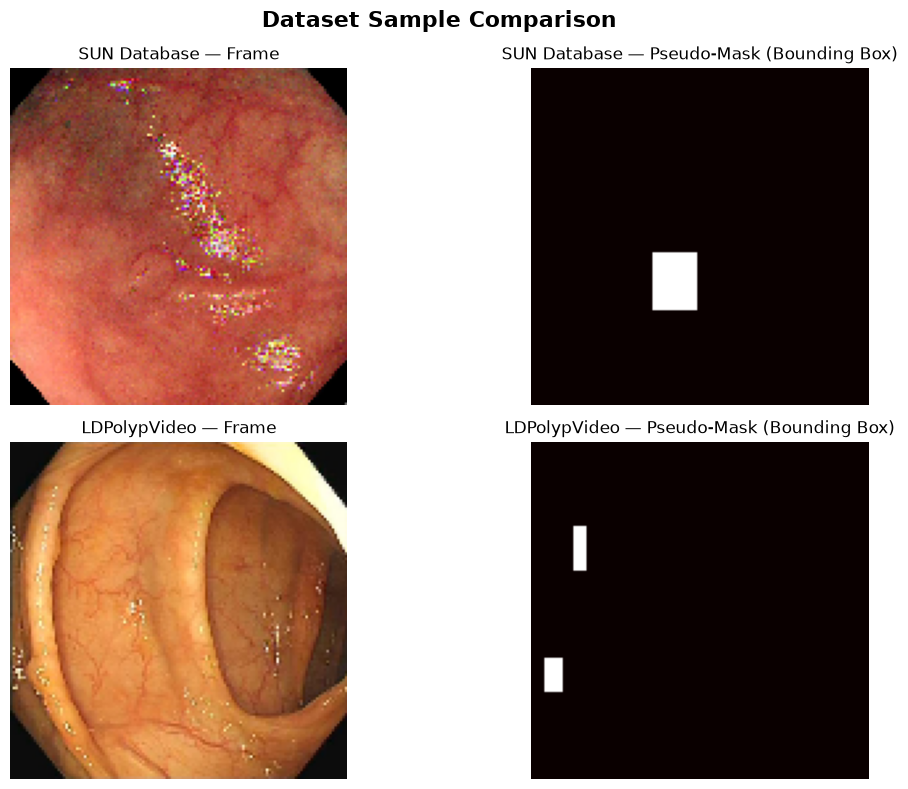

In [3]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Dataset Sample Comparison', fontsize=16, fontweight='bold')

for row, (ds, name) in enumerate([(sun_dataset, 'SUN Database'), (ld_dataset, 'LDPolypVideo')]):
    if len(ds) == 0:
        axes[row, 0].set_title(f'{name} — No samples found')
        axes[row, 1].set_title(f'{name} — No mask available')
        axes[row, 0].axis('off')
        axes[row, 1].axis('off')
        continue

    img, mask = ds[0]
    axes[row, 0].imshow(img.permute(1, 2, 0).numpy())
    axes[row, 0].set_title(f'{name} — Frame')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(mask.squeeze().numpy(), cmap='hot')
    axes[row, 1].set_title(f'{name} — Pseudo-Mask (Bounding Box)')
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()


## 🧠 3. U-Net Model & Metrics (Shared for Both)

In [4]:
def calculate_metrics(pred, target, threshold=0.5):
    pred   = (torch.sigmoid(pred) > threshold).float()
    target = target.float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()
    dice  = (2. * intersection + 1e-6) / (union + 1e-6)
    iou   = (intersection + 1e-6) / (union - intersection + 1e-6)
    acc   = (pred == target).sum() / torch.numel(pred)
    return acc.item(), dice.item(), iou.item()


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.conv(x)

class BasicUNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super().__init__()
        self.inc      = DoubleConv(n_channels, 64)
        self.down1    = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2    = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.up1      = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv_up1 = DoubleConv(256, 128)
        self.up2      = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv_up2 = DoubleConv(128, 64)
        self.outc     = nn.Conv2d(64, n_classes, 1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x  = self.conv_up1(torch.cat([x2, self.up1(x3)], dim=1))
        x  = self.conv_up2(torch.cat([x1, self.up2(x)],  dim=1))
        return self.outc(x)

print('U-Net architecture defined.')

U-Net architecture defined.


## 🏋️ 4. Training Function (Reusable)

In [5]:

def train_and_evaluate(dataset, dataset_name, subset_size=SUBSET, epochs=EPOCHS):
    sample_count = min(subset_size, len(dataset))
    if sample_count < 2:
        raise ValueError(f'{dataset_name} needs at least 2 samples, found {sample_count}.')

    print(f'\n{"="*60}')
    print(f'  Training on: {dataset_name}  ({sample_count} samples)')
    print(f'{"="*60}')

    # ── Subset & split ──
    indices = list(range(sample_count))
    sub = Subset(dataset, indices)
    train_n = max(1, int(0.8 * len(sub)))
    val_n = len(sub) - train_n
    if val_n == 0:
        train_n -= 1
        val_n = 1

    split_generator = torch.Generator().manual_seed(SEED)
    train_ds, val_ds = torch.utils.data.random_split(sub, [train_n, val_n], generator=split_generator)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # ── Fresh model for each dataset ──
    model = BasicUNet().to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    history = {'loss': [], 'acc': [], 'dice': [], 'iou': []}

    for epoch in range(epochs):
        # Training
        model.train()
        total_loss = 0.0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Validation
        model.eval()
        v_acc = v_dice = v_iou = 0.0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                a, d, i = calculate_metrics(model(imgs), masks)
                v_acc += a
                v_dice += d
                v_iou += i

        avg_loss = total_loss / len(train_loader)
        avg_acc = v_acc / len(val_loader)
        avg_dice = v_dice / len(val_loader)
        avg_iou = v_iou / len(val_loader)

        history['loss'].append(avg_loss)
        history['acc'].append(avg_acc)
        history['dice'].append(avg_dice)
        history['iou'].append(avg_iou)

        print(
            f'  Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | '
            f'Acc: {avg_acc:.4f} | Dice: {avg_dice:.4f} | IoU: {avg_iou:.4f}'
        )

    return history

print('Training function ready.')


Training function ready.


## 🚀 5. Run Training on Both Datasets

In [6]:

sun_history = train_and_evaluate(sun_dataset, 'SUN Database')
ld_history = train_and_evaluate(ld_dataset, 'LDPolypVideo TrainValid')



  Training on: SUN Database  (1000 samples)
  Epoch 1/5 | Loss: 0.2299 | Acc: 0.9545 | Dice: 0.6081 | IoU: 0.4434
  Epoch 2/5 | Loss: 0.1100 | Acc: 0.9677 | Dice: 0.7510 | IoU: 0.6074
  Epoch 3/5 | Loss: 0.0762 | Acc: 0.9564 | Dice: 0.7164 | IoU: 0.5633
  Epoch 4/5 | Loss: 0.0616 | Acc: 0.9728 | Dice: 0.7975 | IoU: 0.6675
  Epoch 5/5 | Loss: 0.0489 | Acc: 0.9763 | Dice: 0.8147 | IoU: 0.6895

  Training on: LDPolypVideo TrainValid  (1000 samples)
  Epoch 1/5 | Loss: 0.3382 | Acc: 0.9186 | Dice: 0.3434 | IoU: 0.2131
  Epoch 2/5 | Loss: 0.1940 | Acc: 0.9398 | Dice: 0.6467 | IoU: 0.4931
  Epoch 3/5 | Loss: 0.1436 | Acc: 0.7017 | Dice: 0.3355 | IoU: 0.2124
  Epoch 4/5 | Loss: 0.1122 | Acc: 0.9526 | Dice: 0.7054 | IoU: 0.5685
  Epoch 5/5 | Loss: 0.0880 | Acc: 0.9644 | Dice: 0.6941 | IoU: 0.5705


## 📈 6. Results Comparison — Charts

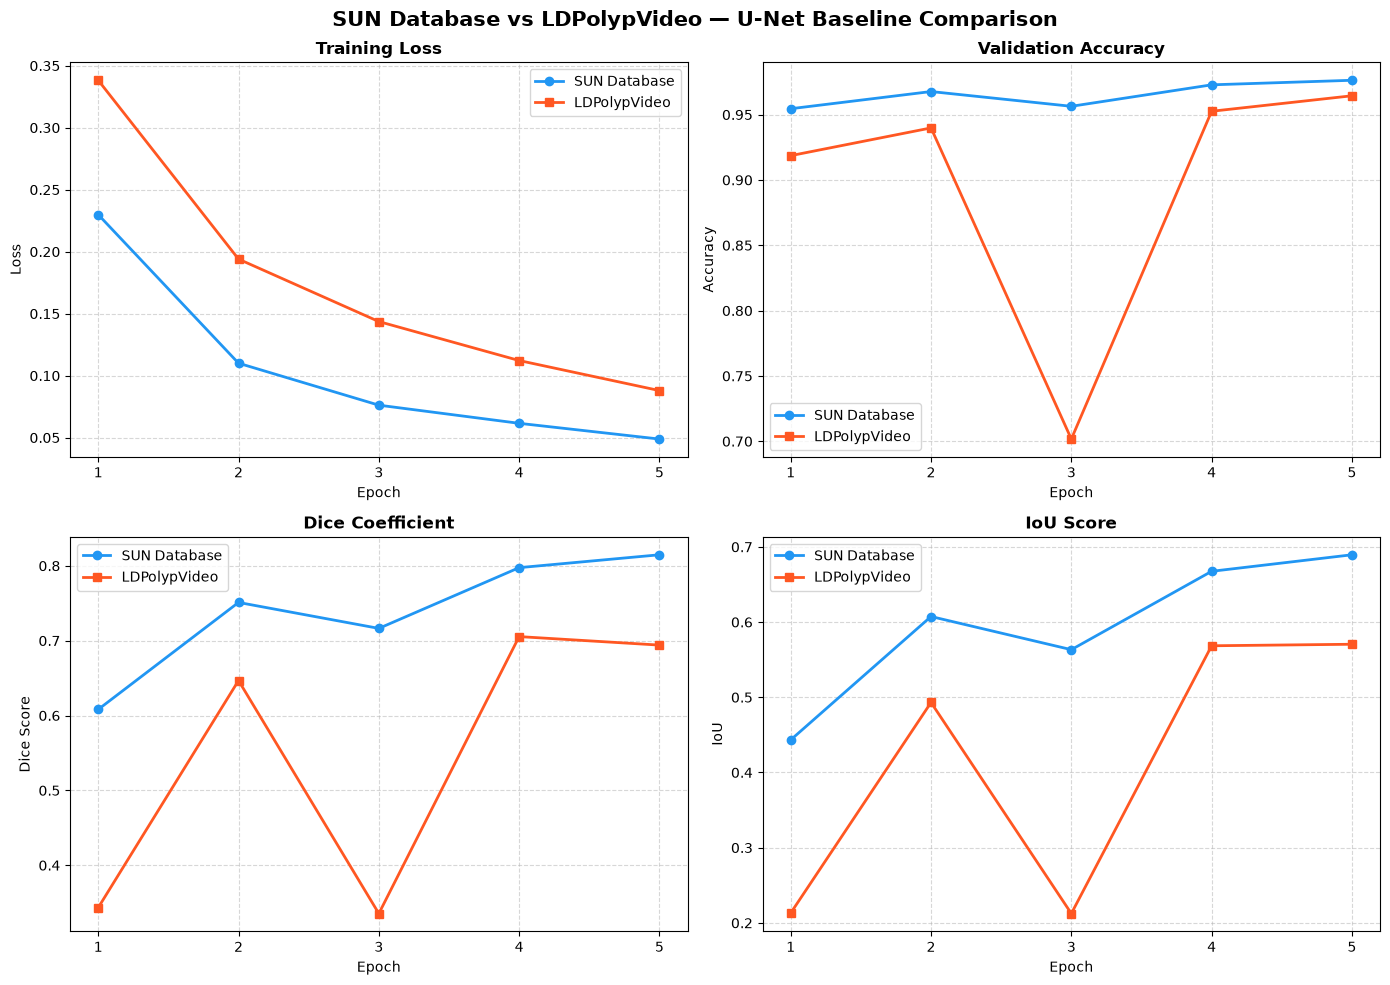

Chart saved as: /Users/alokkumarshukla/Desktop/Major Project 1/comparison_plot.png


In [7]:

epochs_range = range(1, EPOCHS + 1)
metrics = [
    ('loss', 'Training Loss', 'Loss'),
    ('acc', 'Validation Accuracy', 'Accuracy'),
    ('dice', 'Dice Coefficient', 'Dice Score'),
    ('iou', 'IoU Score', 'IoU'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SUN Database vs LDPolypVideo — U-Net Baseline Comparison', fontsize=15, fontweight='bold')

for ax, (key, title, ylabel) in zip(axes.flatten(), metrics):
    ax.plot(epochs_range, sun_history[key], 'o-', color='#2196F3', linewidth=2, markersize=6, label='SUN Database')
    ax.plot(epochs_range, ld_history[key], 's-', color='#FF5722', linewidth=2, markersize=6, label='LDPolypVideo')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xticks(list(epochs_range))

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'comparison_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved as: {PROJECT_ROOT / "comparison_plot.png"}')


## 📋 7. Final Results Summary Table

In [8]:

print('=' * 65)
print(f'{"Metric":<25} {"SUN Database":>18} {"LDPolypVideo":>18}')
print('=' * 65)

labels = [
    ('Best Train Loss', 'loss', min),
    ('Best Val Accuracy', 'acc', max),
    ('Best Dice Score', 'dice', max),
    ('Best IoU Score', 'iou', max),
    ('Final Train Loss', 'loss', lambda x: x[-1]),
    ('Final Dice Score', 'dice', lambda x: x[-1]),
    ('Final IoU Score', 'iou', lambda x: x[-1]),
]

for label, key, fn in labels:
    sv = fn(sun_history[key])
    lv = fn(ld_history[key])
    print(f'{label:<25} {sv:>18.4f} {lv:>18.4f}')

print('=' * 65)
print(f'{"Total Samples":<25} {len(sun_dataset):>18,} {len(ld_dataset):>18,}')
print(f'{"Samples Used":<25} {min(SUBSET, len(sun_dataset)):>18,} {min(SUBSET, len(ld_dataset)):>18,}')
print('=' * 65)


Metric                          SUN Database       LDPolypVideo
Best Train Loss                       0.0489             0.0880
Best Val Accuracy                     0.9763             0.9644
Best Dice Score                       0.8147             0.7054
Best IoU Score                        0.6895             0.5705
Final Train Loss                      0.0489             0.0880
Final Dice Score                      0.8147             0.6941
Final IoU Score                       0.6895             0.5705
Total Samples                         27,728             20,942
Samples Used                           1,000              1,000
